# 0. Approche théorique
## 0.1 Problématique

On souhaite faire une estimation de la masse sèche en fonction des jours (Régression). Nous disposons pour cela de jeux données des mesures de masse sèche faites sur plusieurs jours pour plusieurs récoltes donc plusieurs jours de semis. Aussi nous disposons de données météorologiques concernant les parcelles étudiées pendant une durée qui inclue la durée du semis à la récolte. Les données météo varient (température_max du jour, température_min, humidité_max, humidité_min, évapotranspiration, ensoleillement, précipitation, vent) et les données satellites offrent des images spatio-temporelles de la parcelle en question sur une periode qui inclue les période étudié. Le but est d'utiliser ses données là pour pouvoir prédire l'évolution de la masse sèche pour des plantations futures. 

L'énoncé propose un modèle déterministe dit de Maizy qui se base sur le cumul de degrés-jours (accumulation de la chaleur), sauf que l'utilisation de la température comme seul facteur de prédiction ne permet pas de prendre en considération tous les facteurs nécessaire au développement de la biomasse. *Exemple: un bon cumul de chaleur ne traduit pas forcément un bon développement de la plante dans le cas d'un stress hydrique ou de mauvais ensoleillement.*


## 0.2 Proposition de solution

On propose une amélioration du modèle Maizy de façon à tenir compte d'autres facteurs que la température (stress hydrique, photosynthèse, indice de végétation)

> **Important:** Il faudra qu'on soit cependant attentif sur le nombre de variables (features) qu'on choisit, les données fournies pour entraîner notre modèle présente 182 mesures venant du même bassin de plantation, utiliser toutes les variables sans réduction de dimensionalité peut contraindre la généralisabilité du modèle (curse of dimensionality, overfitting) car beaucoup de dimensions et pas assez de diversité des échantillons (variance petite).

On utilisera le modèle fourni (Maizy) comme baseline pour vérifier si notre proposition améliore la prédiction de la MS.


# 1. Préparation des données

## 1.1 Exploration visuelles des jeux données:

On dispose de 3 sources différentes :

- Un fichier tabulaire contenant pour 142 parcelle: 181 mesure de la masse sèche, la précocité de la récolte, et ses coordonnées géographiques.
- Un fichier tabulaire par parcelle, contenant des données météorologiques prélevées chaque jour sur une vingtaine de mois: températures min et max, précipitation, évapotranspiration, humidité min et max de l'air, radiation solaire, etc.
- Un dossier contenant des données satellitaires cubiques (image+temps) pour chaque parcelle.

Les données utilisées sont de **4 types** : numériques, catégorielles (récolte précoce, semi-précoce, etc.), temporelles (dates) et multi-dimensionnelles (images satelittes spacio-temporelles).

> **Important:** Le fait qu'il y a 181 mesures de 142 parcelles montre que sur certaines parcelles il y a eu plus d'une mesure (selon la date de mesure). Ceci dit, les samples sont identifiés par (parcelle_id, date).


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pandas as pd

# 1. Configuration des chemins
FICHIER_MESURES = Path("data") / "mesures_ms.xlsx" 
DOSSIER_METEO = Path("data") / "meteo"

# 2. Chargement du fichier principal de mesures
df_mesures = pd.read_excel(FICHIER_MESURES, parse_dates=['date', 'sowing_date'])

# --- RECHERCHE AUTOMATIQUE D'UNE PARCELLE REDONDANTE ---
# On compte le nombre d'apparitions de chaque identifiant de parcelle
comptage_parcelles = df_mesures['parcel_id'].value_counts()

# On filtre pour ne garder que celles qui apparaissent plus d'une fois
parcelles_redondantes = comptage_parcelles[comptage_parcelles > 1]

# Sélection automatique de la première parcelle redondante trouvée
ID_PARCELLE_EXEMPLE = parcelles_redondantes.index[0]
nb_apparitions = parcelles_redondantes.iloc[0]

print("On visualise les mesures pour l'une des parcelles redondantes:")
print( f"'{ID_PARCELLE_EXEMPLE}' (présente {nb_apparitions} fois).\n")
print("===============================================================================")

# --- 3. AFFICHAGE DES MESURES (PANDAS HEAD) ---
df_filtre = df_mesures[df_mesures['parcel_id'] == ID_PARCELLE_EXEMPLE]

# 3. Affichage du résultat
print(f"--- APERÇU DES LIGNES DE MESURES POUR LA PARCELLE : {ID_PARCELLE_EXEMPLE} ---")
print(df_filtre)
print("===============================================================================")


On visualise les mesures pour l'une des parcelles redondantes:
'68c925ab41e79a1fe8ddd591' (présente 3 fois).

--- APERÇU DES LIGNES DE MESURES POUR LA PARCELLE : 68c925ab41e79a1fe8ddd591 ---
                    parcel_id       date sowing_date    precocite    MS  \
116  68c925ab41e79a1fe8ddd591 2025-07-22  2025-04-05  DEMI_TARDIF  14.8   
121  68c925ab41e79a1fe8ddd591 2025-07-31  2025-04-05  DEMI_TARDIF  24.2   
147  68c925ab41e79a1fe8ddd591 2025-08-08  2025-04-05  DEMI_TARDIF  27.4   

           lat       lon  
116  46.449653 -0.852229  
121  46.449653 -0.852229  
147  46.449653 -0.852229  


In [2]:
# --- 1. CREATION D'UN DICTIONNAIRE DE DATAFRAMES DES METEOS ---
# Initialisation du dictionnaire
dict_meteo = {}

fichiers_meteo = glob.glob(os.path.join(DOSSIER_METEO, "*.xlsx*"))

for chemin_fichier in fichiers_meteo:
    nom_fichier = os.path.basename(chemin_fichier)
    nom_sans_ext = os.path.splitext(nom_fichier)[0]  
    
    # Extraction du parcelid en enlevant le préfixe "meteo_" 
    id_parcelle = nom_sans_ext.replace("meteo_", "") 
    
    # Lecture du fichier Excel et stockage dans le dictionnaire avec le bon parcelid en clé
    dict_meteo[id_parcelle] = pd.read_excel(chemin_fichier, parse_dates=['time'])

# --- 2. AFFICHAGE DE LA MÉTÉO DE CETTE MÊME PARCELLE ---

print(f"\n--- APERÇU DES 5 PREMIERS JOURS MÉTÉO POUR : {ID_PARCELLE_EXEMPLE} ---")
print(dict_meteo[ID_PARCELLE_EXEMPLE].head(5))
print("===============================================================================")




--- APERÇU DES 5 PREMIERS JOURS MÉTÉO POUR : 68c925ab41e79a1fe8ddd591 ---
        time  temperature_max  temperature_min  precipitation  \
0 2024-01-01             11.5              7.3           10.8   
1 2024-01-02             13.1             11.1           35.3   
2 2024-01-03             12.9             10.2            6.1   
3 2024-01-04             14.0              8.4            1.9   
4 2024-01-05             10.2              2.9            0.7   

   et0_fao_evapotranspiration  wind_speed_10m_max  wind_speed_10m_min  \
0                        0.62                33.1                 7.2   
1                        0.74                35.1                23.1   
2                        1.29                34.6                16.8   
3                        0.84                26.0                 8.0   
4                        0.68                12.0                 3.2   

   shortwave_radiation_sum  wind_direction_10m_dominant  \
0                     2.98          

Pour visualiser les données satelittes, on utilise comme indiqué sur l'énoncé: **zarr** de la bibliothèque **xarray**. Pour une manipulation plus simple de ces données complexes, on créera une classe qui en simplifiera l'usage et l'exploitation: **CubeZarr**.

On créera un dcitionnaire de cubes accessibles par leur id de parcelle à partir de ces objets.

> **Attention:** Sans optimisation matérielle (GPUs, MP) et algo, la création du dicitonnaire prend du temps, des logs sont ajoutés pour suivre l'avancement. 

In [4]:
# Importation de notre classe CubeZarr du fichier cube_utils.py
from CubeZarrUtils import CubeZarr

# 1. Création d'un dictionnaires de CubeZarrs par id de parcelle
dict_cubesZarrs = {}

DOSSIER_CUBES =  Path("data") / "sentinel"

dossiers_cubes = list(DOSSIER_CUBES.glob("*"))

BANDES_CIBLE = ['B04', 'B08']  # Les bandes qui nous intéressent

i = 1
total = len(dossiers_cubes)
print("Chargement en cours :")
for chemin_dossier in dossiers_cubes:
    print(f"\rParcelle : {i}/{total}", end="", flush=True)
    
    nom_dossier = os.path.basename(chemin_dossier)
    
    # Extraction du parcelid en enlevant le suffixe "_l2a" 
    id_parcelle = nom_dossier.replace("_l2a", "") 
    
    # Lecture du fichier Excel et stockage dans le dictionnaire avec le bon parcelid en clé
    dict_cubesZarrs[id_parcelle] = CubeZarr(chemin_dossier, BANDES_CIBLE)

    i += 1

Chargement en cours :
Parcelle : 142/142

Visualisation d'une bande :

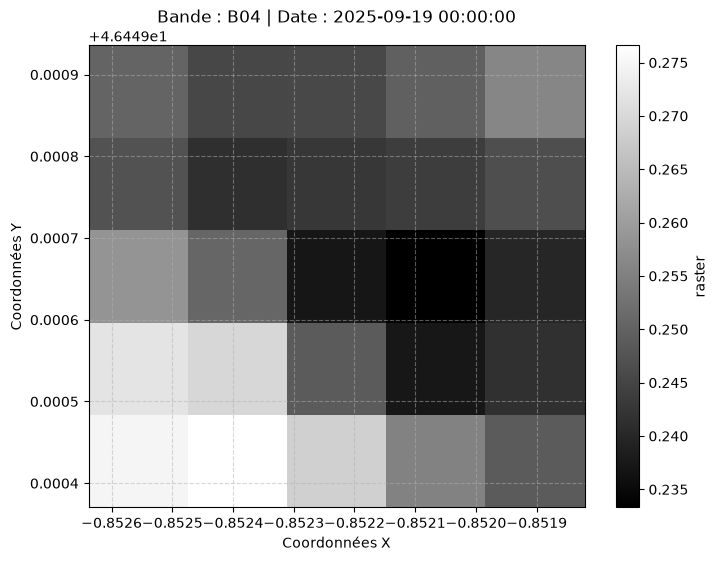

(5, 5)
167
2025-09-19 00:00:00
2017-01-19 00:00:00


In [5]:
# 1. Chargement d'un cube exemple à partir du dictionnaire
cube = dict_cubesZarrs[ID_PARCELLE_EXEMPLE]

# 2. Paramètres de visualisation
JOUR_CIBLE = 0       # Index du jour souhaité 
BANDE_CIBLE = BANDES_CIBLE[0] # Une bande à visualiser: B04

df_cube = cube.dataframe

# 3. Récupération de l'image et de la date
date = cube.date(JOUR_CIBLE)
image_xr = df_cube.loc[df_cube['date'] == date, BANDE_CIBLE].iloc[0]

# 4. Affichage graphique
plt.figure(figsize=(8, 6))
image_xr.plot(cmap='gray')

plt.title(f"Bande : {BANDE_CIBLE} | Date : {date}")
plt.xlabel("Coordonnées X")
plt.ylabel("Coordonnées Y")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 5. Affichage du nombre de jours, et des bornes de l'intervalle temporelle
print(cube.dimension_image())
print(cube.nombre_jours())
print(cube.date(0))
print(cube.date(cube.nombre_jours()-1))


## 1.2 Nettoyage et transformation des données:

On nettoie nos data frames (mesures et météos) des doublons (deux fois la meme dates) et des champs non cohérents (dates qui sont des chiffres) et des champs Nan.

Pour les acquisitions satellites, les masques de nuages sont déjà appliqués (énoncé). Pour les aquisitions nulles, ils sont traitées à l'instanciation du disctionnaire ordonné par dates de chaque cube zarr.

Nous disposons donc de 1 dataframe des mesures à nettoyer, et de 142 dataframes de météo (pour 142 parcelles) que nous allons nettoyer en :

- Eliminant les doublons
- Supprimant les données inexploitable "Nan"
- Assurer les conversions de type si nécessaire

In [6]:
# Supprimer les doublons de mesures ayant la même combinaison de 'parcel_id', 'date' et 'sowing_date'
df_mesures.drop_duplicates(subset=['parcel_id','date', 'sowing_date'], keep='first', inplace=True)
df_mesures.dropna(inplace=True)
df_mesures.reset_index(drop=True, inplace=True)

# Conversion de type des données dates
df_mesures['date'] = pd.to_datetime(df_mesures['date']).dt.normalize()
df_mesures['sowing_date'] = pd.to_datetime(df_mesures['sowing_date']).dt.normalize()

for cle, df in dict_meteo.items():
    # Supprimer les doublons de météo ayant la même date pour une parcelle donnée
    df.drop_duplicates(subset=['time'], keep='first', inplace=True)

    # On supprime TOUTES les lignes qui contiennent au moins un NaN
    df.dropna(inplace=True)
    
    # On réinitialise les index proprement
    df.reset_index(drop=True, inplace=True)

    df['time'] = pd.to_datetime(df['time']).dt.normalize()



Pour les données catégorielles, on attribuera à chaque précocité un entier selon son degré 0 étant "précoce" et 2 étant "semi-tardif"/"tardif".

Pour la gestion des données manquantes, vu qu'à priori on utilisera la variable de précocité uniquement pour trouver les facteurs a et b dans la formule de Maizy en les utilisants comme des flags, on attribuera aux précocités inconnues la valeur 3 pour utiliser une moyenne des facteurs et éviter debruiter les valeurs de Maizy calculées.

In [7]:
# 1. Définition du dictionnaire de correspondance 
dictionnaire_encodage = {
    'PRECOCE': 0,
    'DEMI_PRECOCE': 1,
    'DEMI_TARDIF': 2,
    'TARDIF': 2,
    'INCONNU' : 3,
}

# 2. Remplacement direct dans la même colonne
df_mesures['precocite'] = df_mesures['precocite'].map(dictionnaire_encodage)

# 3. Vérification du résultat
print("--- APERÇU DE LA COLONNE PRÉCOCITÉ MODIFIÉE ---")
print(df_mesures.head(10))

--- APERÇU DE LA COLONNE PRÉCOCITÉ MODIFIÉE ---
                  parcel_id       date sowing_date  precocite    MS  \
0  68d10ed7118c98a20beae5e2 2024-09-10  2024-05-31          0  25.0   
1  68d10edc118c98a20beae600 2024-09-10  2024-05-11          2  29.0   
2  68d10edc118c98a20beae61e 2024-09-10  2024-05-11          2  30.5   
3  68d10edd118c98a20beae63c 2024-09-10  2024-05-31          2  27.0   
4  68d10edd118c98a20beae65a 2024-09-10  2024-05-10          2  32.0   
5  68d10ede118c98a20beae678 2024-09-10  2024-06-11          0  27.0   
6  68d10ede118c98a20beae696 2024-09-10  2024-06-04          1  25.0   
7  68d10edf118c98a20beae6b4 2024-09-10  2024-06-02          1  31.0   
8  68d10ee0118c98a20beae6d2 2024-09-10  2024-06-15          1  25.0   
9  68d10ee0118c98a20beae6f0 2024-09-10  2024-06-12          3  25.0   

         lat       lon  
0  46.641174 -1.211277  
1  46.650187 -1.225448  
2  46.651811 -1.241121  
3  46.582070 -1.312653  
4  46.590356 -1.323587  
5  46.580964 -1.1603

## 1.3 Split Train/Test:

Notre jeu de données est de 182 samples. Les mesures concernent 141 parcelles et deux récoltes (deux années). D'un point de vue agronomique, le cas d'usage classique est de mettre 1 année de côté pour le test. pour notre cas on divisera les 182 mesures en 2 sous-groupes : 2024 et 2025.


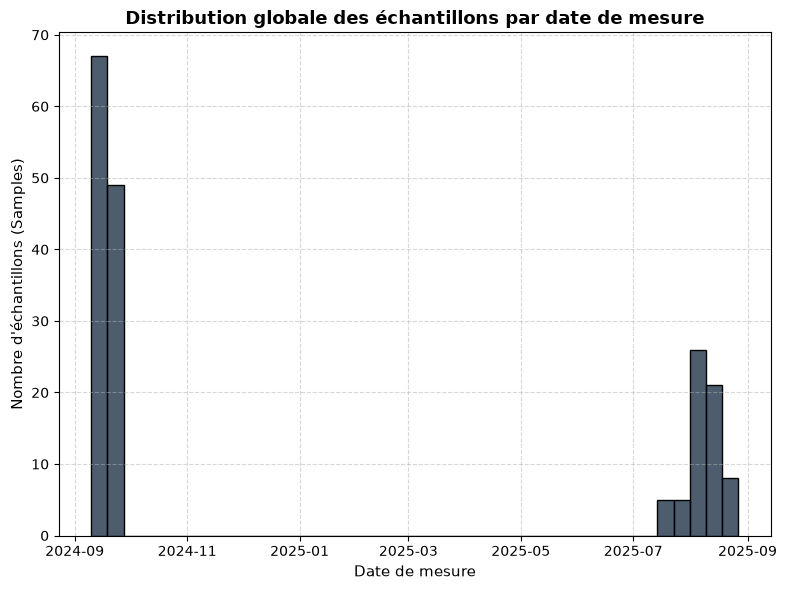

In [8]:
import seaborn as sns

# 1. Configuration de la dimension du graphique
plt.figure(figsize=(8, 6))

# 2. Génération de l'histogramme global
# stat='count' permet d'avoir le nombre exact d'échantillons par barre
sns.histplot(data=df_mesures, x='date', color='#2e4053', bins=40, alpha=0.85, stat='count')

# 3. Personnalisation esthétique
plt.title("Distribution globale des échantillons par date de mesure", fontsize=13, fontweight='bold')
plt.xlabel("Date de mesure", fontsize=11)
plt.ylabel("Nombre d'échantillons (Samples)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Affichage
plt.tight_layout()
plt.show()


De cet histogramme, il en ressort que l'année contenant le plus de samples est 2024. C'est l'année qui sera utilisée pour l'entrâinement.

In [9]:
date_sep = pd.Timestamp('2024-11-01')

df_mesures_train = df_mesures[df_mesures['date'] < date_sep]
df_mesures_test = df_mesures[df_mesures['date'] >= date_sep]

print("Train :", len(df_mesures_train), "samples") 
print("Test :", len(df_mesures_test), "samples") 

Train : 116 samples
Test : 65 samples


## 1.4 Fusion de données

Pour mieux choisir nos features, on pratiquera une fusion des données en une seule dataframe (mesures) on y intégrera des valeurs aggrégées des données météo sur toute la période du semis jusqu'au moment de la mesure de la MS, pour contenir l'information nécessaire à partir des données météo et satellite pour chaque mesure en une seule ligne. Ceci permettra un bon feature engineering.

On crée des fonctions de fusion de données pour aggréger une partie d'une colonne d'un dataframe en une seule valeur. Elles sont importables depuis le fichier **AggregUtils.py**.

On **fusionne** les données de **dict_meteo** et **dict_cubesZarrs** dans les data frames **df_mesures_train** et **df_mesures_test**.

In [10]:
from AggregUtils import DJc, RGc, Pc, ETPc, NDVI
from Maizy import Maizy

df_mesures_train['djc'] = df_mesures_train.apply(
    DJc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_train['ndvi'] = df_mesures_train.apply(
    NDVI, 
    axis=1, 
    args=(dict_cubesZarrs,)
)

df_mesures_train['rgc'] = df_mesures_train.apply(
    RGc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_train['pc'] = df_mesures_train.apply(
    Pc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_train['etpc'] = df_mesures_train.apply(
    ETPc, 
    axis=1, 
    args=(dict_meteo,)
)

print(df_mesures_train.head(10))

                  parcel_id       date sowing_date  precocite    MS  \
0  68d10ed7118c98a20beae5e2 2024-09-10  2024-05-31          0  25.0   
1  68d10edc118c98a20beae600 2024-09-10  2024-05-11          2  29.0   
2  68d10edc118c98a20beae61e 2024-09-10  2024-05-11          2  30.5   
3  68d10edd118c98a20beae63c 2024-09-10  2024-05-31          2  27.0   
4  68d10edd118c98a20beae65a 2024-09-10  2024-05-10          2  32.0   
5  68d10ede118c98a20beae678 2024-09-10  2024-06-11          0  27.0   
6  68d10ede118c98a20beae696 2024-09-10  2024-06-04          1  25.0   
7  68d10edf118c98a20beae6b4 2024-09-10  2024-06-02          1  31.0   
8  68d10ee0118c98a20beae6d2 2024-09-10  2024-06-15          1  25.0   
9  68d10ee0118c98a20beae6f0 2024-09-10  2024-06-12          3  25.0   

         lat       lon      djc      ndvi      rgc     pc    etpc  
0  46.641174 -1.211277  1278.20  0.641187  2040.84  186.0  385.58  
1  46.650187 -1.225448  1446.25  0.783407  2402.73  251.1  442.81  
2  46.651811 -

Traitement des lignes où pas de ndvi possible : On les remplace par la moyenne pour lisser et éviter qu'ils ne bruitent le data frame général

In [11]:
moyenne = df_mesures_train["ndvi"].replace(-1, np.nan).mean()
df_mesures_train["ndvi"] = df_mesures_train["ndvi"].replace(-1, moyenne)

Nous avons donc intégré 5 nouvelles features aggrégés : Degrés jours cumulés, Evapotranspiration cumulée, les precipitations cumulées, le NDVI et le rayonnement global cumulé.

In [12]:
df_mesures_test['djc'] = df_mesures_test.apply(
    DJc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_test['ndvi'] = df_mesures_test.apply(
    NDVI, 
    axis=1, 
    args=(dict_cubesZarrs,)
)

df_mesures_test['rgc'] = df_mesures_test.apply(
    RGc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_test['pc'] = df_mesures_test.apply(
    Pc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_test['etpc'] = df_mesures_test.apply(
    ETPc, 
    axis=1, 
    args=(dict_meteo,)
)

df_mesures_test['maizy'] = df_mesures_test.apply(
    Maizy, 
    axis=1, 
)

print(df_mesures_test.head(10))

                    parcel_id       date sowing_date  precocite    MS  \
116  68c925ab41e79a1fe8ddd591 2025-07-22  2025-04-05          2  14.8   
117  68c925ac41e79a1fe8ddd5af 2025-07-22  2025-04-05          2  17.1   
118  68c925ad41e79a1fe8ddd5cd 2025-07-22  2025-04-05          2  15.2   
119  68c925ad41e79a1fe8ddd5eb 2025-07-22  2025-04-05          2  20.3   
120  68c925ae41e79a1fe8ddd609 2025-07-22  2025-04-05          2  16.6   
121  68c925ab41e79a1fe8ddd591 2025-07-31  2025-04-05          2  24.2   
122  68c925ac41e79a1fe8ddd5af 2025-07-31  2025-04-05          2  21.9   
123  68c925ad41e79a1fe8ddd5cd 2025-07-31  2025-04-05          2  27.0   
124  68c925ad41e79a1fe8ddd5eb 2025-07-31  2025-04-05          2  28.5   
125  68c925ae41e79a1fe8ddd609 2025-07-31  2025-04-05          2  26.3   

           lat       lon     djc      ndvi      rgc     pc    etpc      maizy  
116  46.449653 -0.852229  1299.4  0.805556  2454.43  216.3  468.07  20.248497  
117  46.450786 -0.852122  1299.4  0.

In [13]:
moyenne = df_mesures_test["ndvi"].replace(-1, np.nan).mean()
df_mesures_test["ndvi"] = df_mesures_test["ndvi"].replace(-1, moyenne)

# 2. Feature Selection, Scaling, Engineering

## 2.1 Boxplot

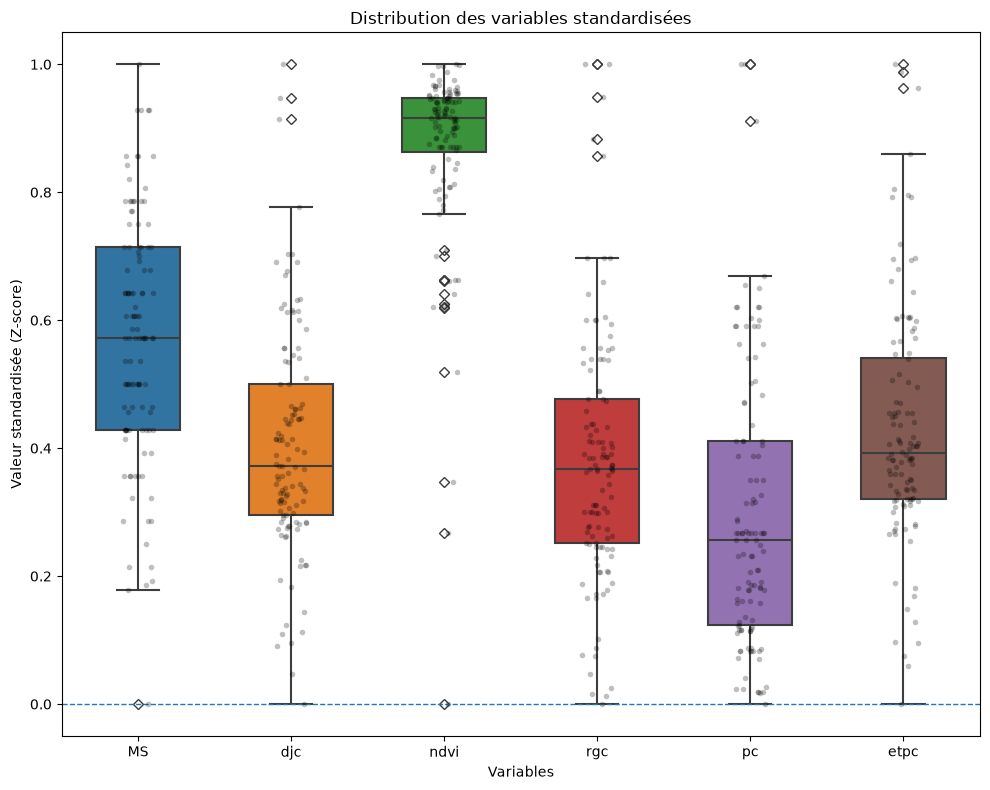

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

variables_a_tracer = ["MS", "djc", "ndvi", "rgc", "pc", "etpc"]
df_scaled = df_mesures_train[variables_a_tracer].copy()
# Standardisation
scaler = MinMaxScaler()

df_scaled[variables_a_tracer] = scaler.fit_transform(
    df_mesures_train[variables_a_tracer]
)

plt.figure(figsize=(10, 8))

sns.boxplot(
    data=df_scaled,
    orient="v",
    width=0.55,
    flierprops={
        "marker": "D",
        "markersize": 5,
    },
    linewidth=1.5,
)

sns.stripplot(
    data=df_scaled,
    orient="v",
    alpha=0.25,
    color="black",
    size=4,
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.ylabel("Valeur standardisée (Z-score)")
plt.xlabel("Variables")
plt.title("Distribution des variables standardisées")

plt.tight_layout()
plt.show()

## 2.2 Heatmap

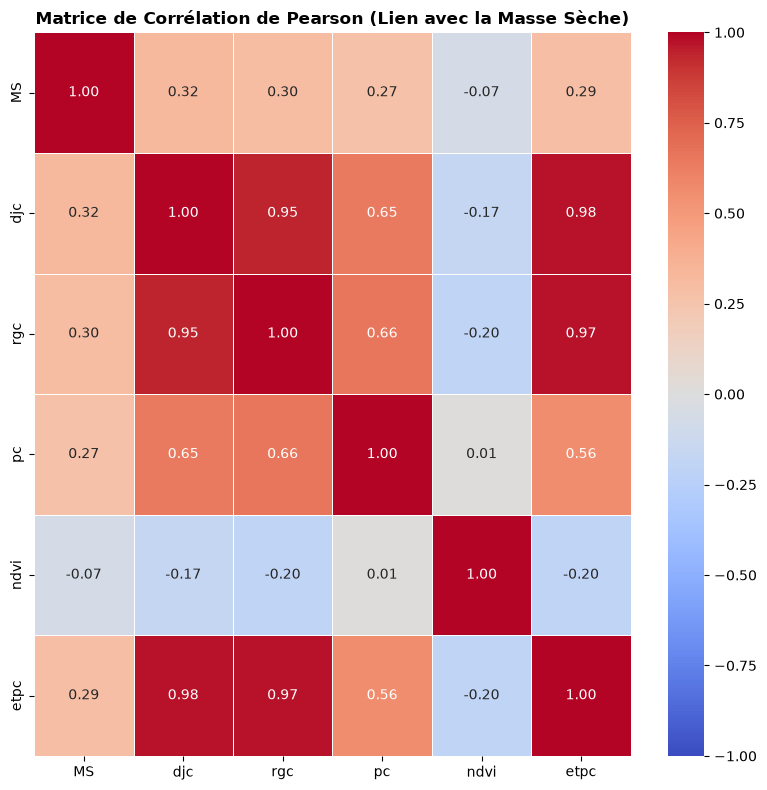

In [15]:
plt.figure(figsize=(8, 8))
variables_a_tracer = ["MS", "djc", "rgc", "pc", "ndvi", "etpc",  ]

# Calcul de la matrice de corrélation de Pearson
corr = df_mesures_train[variables_a_tracer].corr()

# Affichage de la carte thermique (Heatmap)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)

plt.title("Matrice de Corrélation de Pearson (Lien avec la Masse Sèche)", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

## 2.3 Point Cloud Pairplot

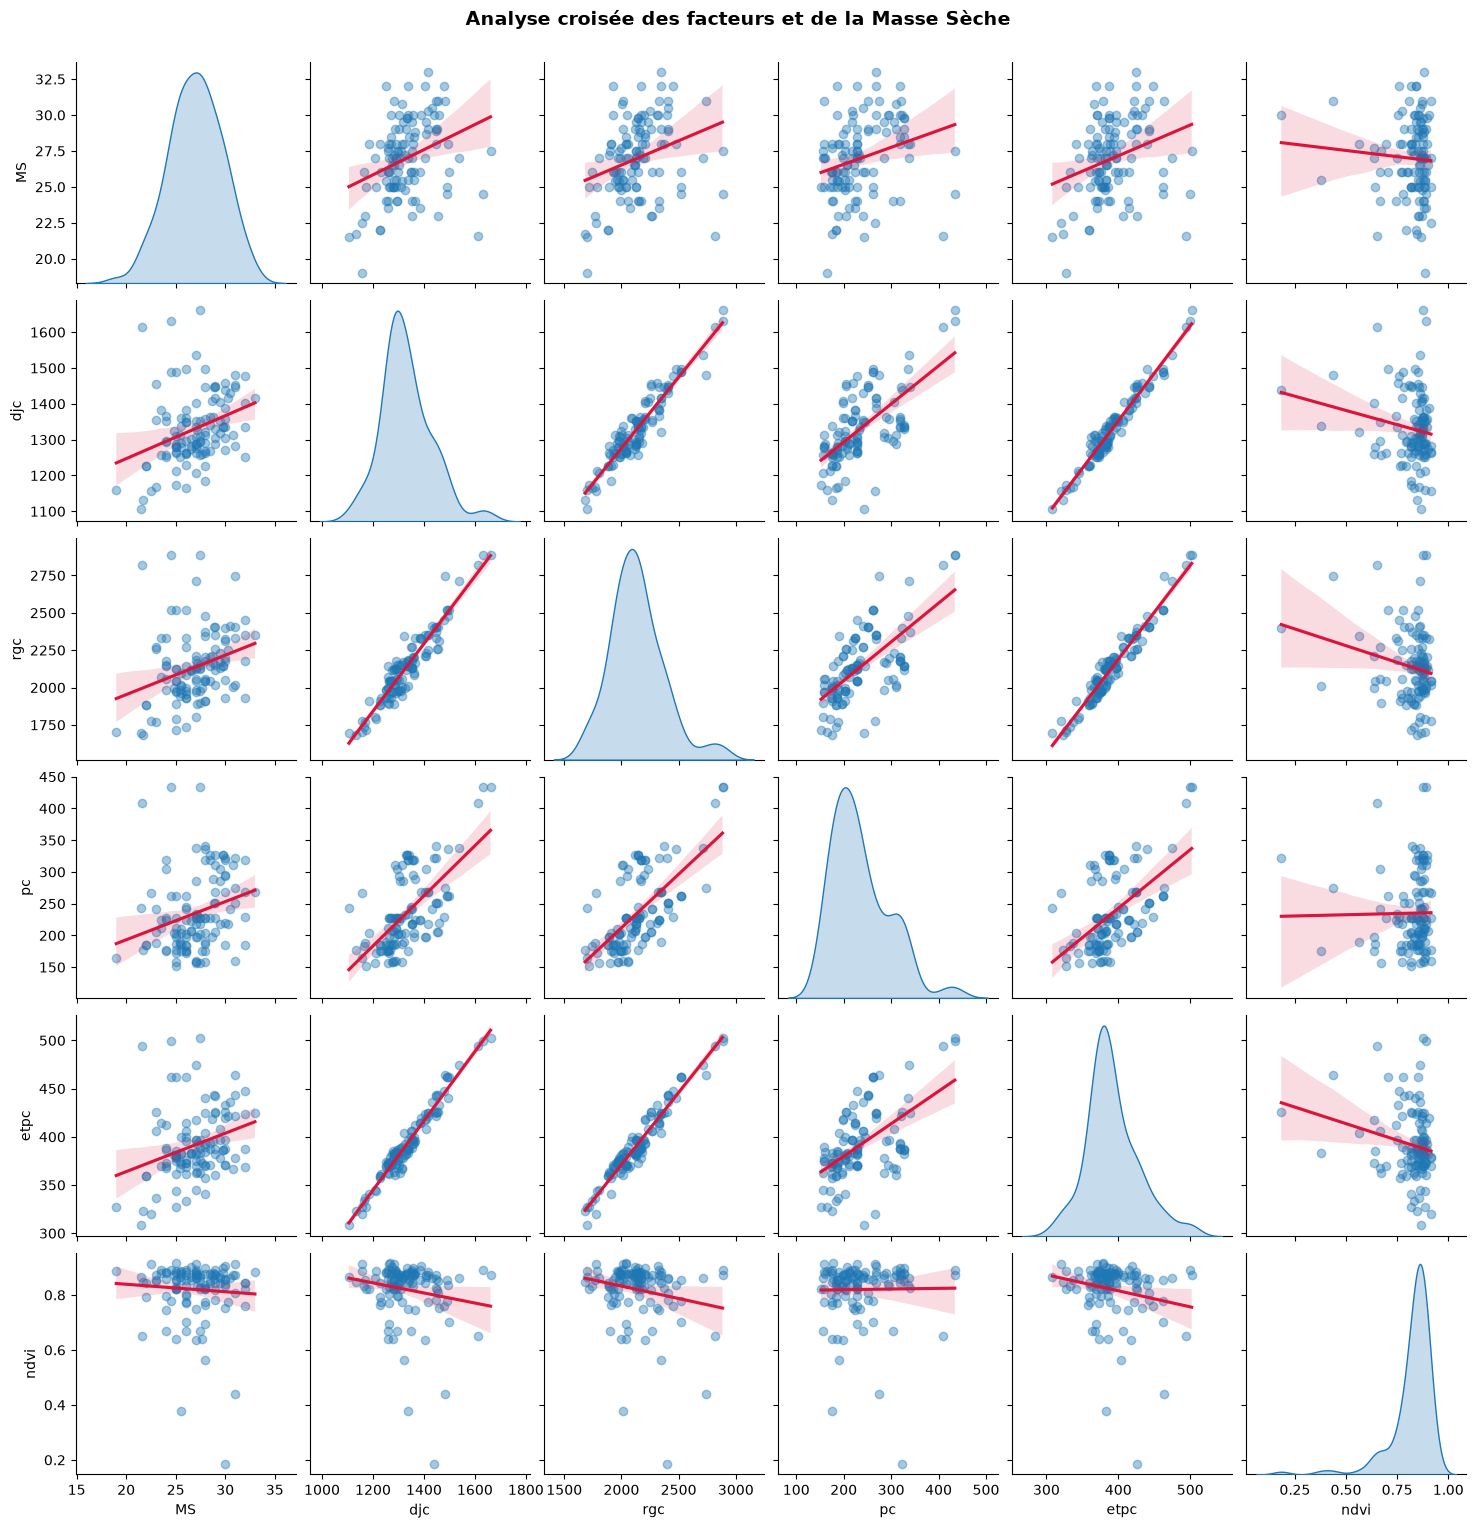

In [16]:

# Sélection des variables numériques
variables_a_tracer = ["MS", "djc", "rgc", "pc", "etpc", "ndvi",  ]

# Tracé de la matrice globale
g = sns.pairplot(df_mesures_train[variables_a_tracer], kind="reg", diag_kind="kde", 
                 plot_kws={'line_kws':{'color':'crimson'}, 'scatter_kws': {'alpha': 0.4}})

g.fig.suptitle("Analyse croisée des facteurs et de la Masse Sèche", y=1.02, fontsize=14, weight="bold")

plt.show()


## Gesiton d'Outliers

Les outlier sont sur les cumuls météo et ne sont pas d'erreurs de capteur, mais le reflet d'une réalité climatique extrême (une année de canicule historique ou un orage exceptionnel). Il n'ya pas de outlier sur la mesure de MS.

Les variables rgc (rayonnement global) et etpc (cumul d'evapotranspi) sont fortement corrélés avec la variable (djc) cumul jours. Nous allors choisir pour l'entraînement que 3 features donc : djc, pc (précipitations cumulées et le ndvi).

# 3. Model Training

On entraîne un Random Forest de Régresion et le tronquons sur la profondeur pour éviter de overfit sur notre data set réduit.

## 3.1 Entraînement

In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------------------------------
# 1. PRÉPARATION DES MATRICES (X et y)
# -------------------------------------------------------------------------

features = ["djc", "pc", "ndvi"]
target = "MS"

X_train_raw = df_mesures_train[features].values
y_train = df_mesures_train[target].values

# -------------------------------------------------------------------------
# 2. CONFIGURATION DU VALIDATION SPLIT (K-Fold)
# -------------------------------------------------------------------------

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_r2_val = []
scores_mae_val = []

print(f"--- Lancement de la Validation Croisée (5-Fold) ---")
print(f"Nombre total d'échantillons de Train : {len(X_train_raw)}\n")

# Boucle de validation croisée
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_raw, y_train)):
    X_tr, X_val = X_train_raw[train_idx], X_train_raw[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)

    rf_fold = RandomForestRegressor(
        n_estimators=100,
        max_depth=3,  
        min_samples_leaf=2, 
        random_state=42,
        n_jobs=-1,
    )

    rf_fold.fit(X_tr_scaled, y_tr)
    preds_val = rf_fold.fit(X_tr_scaled, y_tr).predict(X_val_scaled)

    r2 = r2_score(y_val, preds_val)
    mae = mean_absolute_error(y_val, preds_val)

    scores_r2_val.append(r2)
    scores_mae_val.append(mae)

    print(
        f"Fold {fold+1} : Échantillons = {len(X_tr)} | R² Validation = {r2:.3f} | MAE = {mae:.2f}"
    )

# -------------------------------------------------------------------------
# 3. PERFORMANCES MOYENNES DU MODÈLE SUR LE TRAIN DE 116 LIGNES
# -------------------------------------------------------------------------
print("\n--- SYNTHÈSE DE LA VALIDATION ---")
print(f"R² moyen de Validation : {np.mean(scores_r2_val):.3f}")
print(f"MAE moyenne de Validation : {np.mean(scores_mae_val):.2f}\n")

# -------------------------------------------------------------------------
# 4. ENTRAÎNEMENT FINAL SUR LA TOTALITÉ DES 116 LIGNES
# -------------------------------------------------------------------------
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_raw)

rf_final = RandomForestRegressor(
    n_estimators=100, max_depth=3, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_final.fit(X_train_scaled_final, y_train)

print("--- IMPORTANCE FINALE DES VARIABLES ---")
for name, importance in zip(features, rf_final.feature_importances_):
    print(f"{name:<20} : {importance*100:.2f}%")

--- Lancement de la Validation Croisée (5-Fold) ---
Nombre total d'échantillons de Train : 116

Fold 1 : Échantillons = 92 | R² Validation = 0.110 | MAE = 2.42
Fold 2 : Échantillons = 93 | R² Validation = 0.225 | MAE = 1.65
Fold 3 : Échantillons = 93 | R² Validation = 0.460 | MAE = 1.10
Fold 4 : Échantillons = 93 | R² Validation = -0.107 | MAE = 2.26
Fold 5 : Échantillons = 93 | R² Validation = 0.183 | MAE = 1.62

--- SYNTHÈSE DE LA VALIDATION ---
R² moyen de Validation : 0.174
MAE moyenne de Validation : 1.81

--- IMPORTANCE FINALE DES VARIABLES ---
djc                  : 57.53%
pc                   : 33.62%
ndvi                 : 8.85%


# 3.2 Validation

TABLEAU COMPARATIF
         Modèle    R²    MAE  Erreur max  MAPE (%)
0  Notre modèle  0.30  3.326      12.003    16.041
1         Maizy  0.33  3.472       7.983    15.487


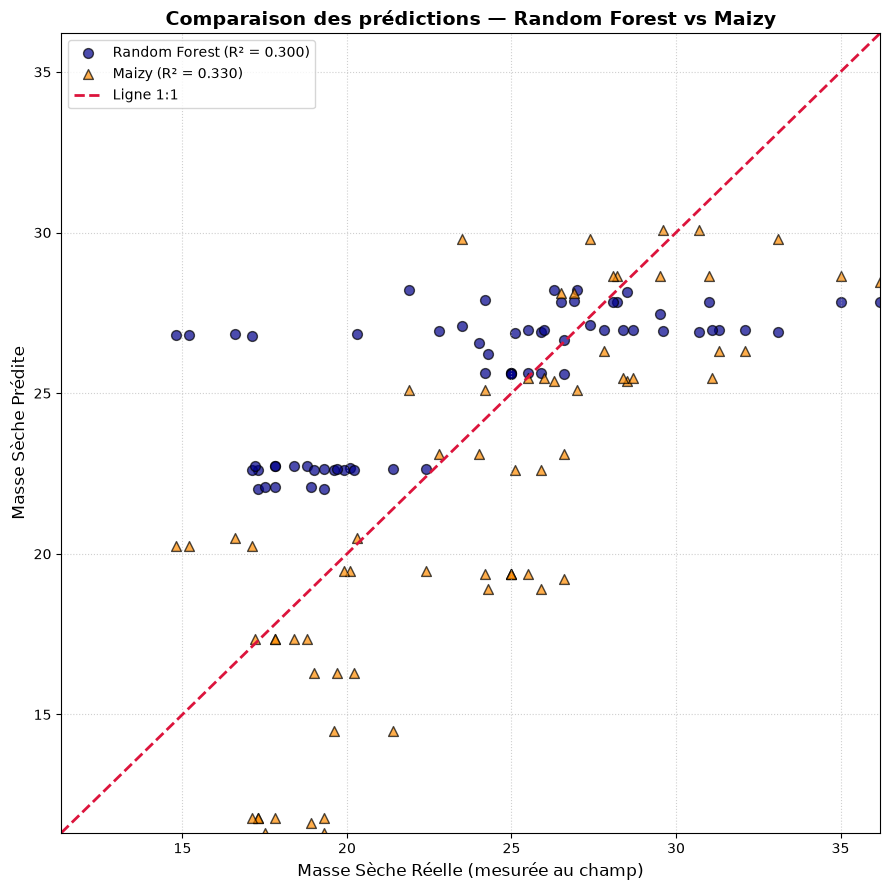

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import max_error, mean_absolute_error, r2_score

# -------------------------------------------------------------------------
# 1. PRÉPARATION ET STANDARDISATION DU JEU DE TEST (62 samples)
# -------------------------------------------------------------------------

features = ["djc", "pc", "ndvi"]
target = "MS"

X_test_raw = df_mesures_test[features].values
y_test = df_mesures_test[target].values

X_test_scaled = scaler_final.transform(X_test_raw)

# -------------------------------------------------------------------------
# 2. PRÉDICTIONS ET COMPARAISON RF vs MAIZY
# -------------------------------------------------------------------------

# Prédictions Random Forest
predictions_test = rf_final.predict(X_test_scaled)

# Résultats Maizy
predictions_maizy = df_mesures_test["maizy"].values


def calcul_metriques(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    erreur_max = max_error(y_true, y_pred)

    # MAPE en évitant les divisions par zéro
    masque = y_true != 0
    mape = np.mean(
        np.abs((y_true[masque] - y_pred[masque]) / y_true[masque])
    ) * 100

    return r2, mae, erreur_max, mape


# Métriques Random Forest
r2_rf, mae_rf, max_rf, mape_rf = calcul_metriques(
    y_test, predictions_test
)

# Métriques Maizy
r2_maizy, mae_maizy, max_maizy, mape_maizy = calcul_metriques(
    y_test, predictions_maizy
)


# -------------------------------------------------------------------------
# 3. TABLEAU COMPARATIF
# -------------------------------------------------------------------------
print("=============================================================================")
print("TABLEAU COMPARATIF")
print("=============================================================================")
resultats = pd.DataFrame({
    "Modèle": ["Notre modèle", "Maizy"],
    "R²": [r2_rf, r2_maizy],
    "MAE": [mae_rf, mae_maizy],
    "Erreur max": [max_rf, max_maizy],
    "MAPE (%)": [mape_rf, mape_maizy]
})

print(resultats.round(3))
print("=============================================================================")

# -------------------------------------------------------------------------
# 4. GRAPHIQUE RF vs MAIZY
# -------------------------------------------------------------------------

plt.figure(figsize=(9, 9))

# Random Forest
plt.scatter(
    y_test,
    predictions_test,
    color="darkblue",
    alpha=0.7,
    edgecolors="k",
    s=50,
    label=f"Random Forest (R² = {r2_rf:.3f})"
)

# Maizy
plt.scatter(
    y_test,
    predictions_maizy,
    color="darkorange",
    alpha=0.7,
    edgecolors="k",
    s=50,
    marker="^",
    label=f"Maizy (R² = {r2_maizy:.3f})"
)

# Ligne 1:1
lims = [
    min(y_test.min(), predictions_test.min(), predictions_maizy.min()),
    max(y_test.max(), predictions_test.max(), predictions_maizy.max())
]

plt.plot(
    lims,
    lims,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="Ligne 1:1"
)

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Masse Sèche Réelle (mesurée au champ)", fontsize=12)
plt.ylabel("Masse Sèche Prédite", fontsize=12)

plt.title(
    "Comparaison des prédictions — Random Forest vs Maizy",
    fontsize=14,
    weight="bold"
)

plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()